In [1]:
# 1: Bib
import os
import re
import json
import csv
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)
from datetime import datetime




In [2]:

# 2: Dataset Class: transfer CSV in PyTorch.
class GazeDataset(Dataset):

    def __init__(self, csv_file, transform=None, dataset_size=None, read_all4once=True):

        self.df = pd.read_csv(csv_file)
        self.transform = transform
        self.dataset_size = dataset_size if dataset_size is not None else len(self.df)
        self.read_all4once = read_all4once

        if self.read_all4once:
            img = Image.new("RGB", (500, 300))  # any size
            out = transform(img)
            self.images = torch.zeros([self.dataset_size] + list(out.shape))
            self.targets = torch.zeros(self.dataset_size, 2)

        for idx in tqdm(range(self.dataset_size)):

            row = self.df.iloc[idx]

            image = Image.open(
                row["image_name"]
            ).convert("RGB")

            self.targets[idx] = torch.tensor(
                [row["x"], row["y"]],
                dtype=torch.float32
            )

            if self.transform:
                self.images[idx] = self.transform(image)
            else:
                self.images[idx] = image

    def __len__(self):

        return self.dataset_size

    def __getitem__(self, idx):

        return self.images[idx], self.targets[idx]

In [3]:

# 3: Normalization:

def normalize(in_path, out_path):

    DATASET_ROOT = Path(in_path)

    OUTPUT_DIR = Path(out_path)

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    IMAGES_DIR = OUTPUT_DIR / "images"

    csv_path = OUTPUT_DIR / "norm_labels.csv"

    with open(csv_path, "w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)

        writer.writerow([
            "image_name",
            "x",
            "y",
            "subject_ID",
            "screen_w",
            "screen_h"
        ])

        total_images = 0
        total_subjects = 0

        # ======================================================
        # Alle Subjekte durchlaufen
        # ======================================================

        for outer_subject_dir in sorted(DATASET_ROOT.iterdir()):

            if not outer_subject_dir.is_dir():
                continue

            subject_id = outer_subject_dir.name

            inner_subject_dir = (
                outer_subject_dir / subject_id
            )

            if not inner_subject_dir.exists():
                continue

            # ==================================================
            # Dateien laden
            # ==================================================

            frames_file = (
                inner_subject_dir / "frames.json"
            )

            dotinfo_file = (
                inner_subject_dir / "dotInfo.json"
            )

            frames_folder = (
                inner_subject_dir / "frames"
            )

            screen_file = (
                    inner_subject_dir / "screen.json"
            )

            # --------------------------------------------------
            if not frames_file.exists():
                print(f"Skipping {subject_id}: frames.json missing")
                continue

            if not dotinfo_file.exists():
                print(f"Skipping {subject_id}: dotInfo.json missing")
                continue

            if not frames_folder.exists():
                print(f"Skipping {subject_id}: frames folder missing")
                continue

            if not screen_file.exists():
                print(f"Skipping {subject_id}: frames folder missing")
                continue
            # --------------------------------------------------

            try:
                with open(frames_file, "r", encoding="utf-8") as f:
                    frame_names = json.load(f)

                with open(dotinfo_file, "r", encoding="utf-8") as f:
                    dot_info = json.load(f)

                with open(screen_file, "r", encoding="utf-8") as f:
                    screen_info = json.load(f)

            except Exception as e:
                print(f"Skipping {subject_id}: JSON read error --> {e}")

            try:
                x_values = dot_info["XPts"]
                y_values = dot_info["YPts"]

                h_values = screen_info["H"]
                w_values = screen_info["W"]
                orientation_values = screen_info["Orientation"]

            except KeyError as e:
                print(f"Skipping {subject_id}: missing key --> {e}")

            if len(frame_names) != len(x_values):
                print(
                    f"ERROR in {subject_id}: "
                    f"{len(frame_names)} frames but "
                    f"{len(x_values)} labels"
                )
                continue

            total_subjects += 1

            # ==================================================
            # Alle Frames bearbeiten
            # ==================================================

            for idx in range(len(frame_names)):

                original_image_name = frame_names[idx]

                x = x_values[idx]
                y = y_values[idx]

                screen_h = h_values[idx]
                screen_w = w_values[idx]

                orientation = orientation_values[idx]


                if orientation == 1 and screnn_w > screen_h:
                    # Portrait
                    x_corr = x
                    y_corr = y
                
                elif orientation == 2:
                    # Portrait upside down
                    x_corr = screen_w - x
                    y_corr = screen_h - y
                
                elif orientation == 3:
                    # Landscape Left
                    x_corr = y
                    y_corr = screen_w - x
                
                elif orientation == 4:
                    # Landscape Right
                    x_corr = screen_h - y
                    y_corr = x
                
                else:
                    x_corr = x
                    y_corr = y


                # Normalisation:
                # x_norm = x / screen_w
                # y_norm = y / screen_h

                x_norm = min(max(0, (x_corr / screen_w)), 1)
                y_norm = min(max(0, (y_corr / screen_h)), 1)


                source_image = (
                    frames_folder /
                    original_image_name
                )

                if not source_image.exists():
                    print(
                        f"Missing image: {source_image}"
                    )
                    continue


                writer.writerow([
                    source_image,
                    x_norm,
                    y_norm,
                    subject_id,
                    screen_w,
                    screen_h
                ])

                total_images += 1


    print()
    print("=" * 50)
    print(f"{'#'*10} Normalisation DONE {'#'*10}")
    print("=" * 100)
    print(f"Subjects processed : {total_subjects}")
    print(f"Images processed   : {total_images}")
    print(f"CSV saved to       : {csv_path}")

In [4]:

# 4: func-Screen-size:
def find_screen_size():
    # Checking for normalize-file (norm_labels.csv):
    dataset_path = './dataset/images/'
    if not os.path.exists('./dataset/norm_labels.csv'):

        print(f"The file: 'norm_labels.csv' is maybe needed, but doesn't find!\n Try to create it ... \n")
        normalize(dataset_path, "./dataset/")

        if os.path.exists('./dataset/norm_labels.csv'):
            print(f"Now can find the file: 'norm_labels.csv' !\n ")

    """Suche die Bildschirmbreite aus einer Datei mit screen_w und screen_h"""
    candidates = [
        # "norm_labels.py",
        # "dataset/labels.csv",
        "dataset/norm_labels.csv"
    ]

    for path in candidates:
        if not os.path.exists(path):
            continue

        if path.endswith(".csv"):
            try:
                df = pd.read_csv(path)
            except Exception:
                continue
            if "screen_w" and "screen_h" in df.columns:
                return float(df["screen_w"].iloc[0]), float(df["screen_h"].iloc[0])
        else:
            try:
                with open(path, "r", encoding="utf-8") as f:
                    content = f.read()
            except Exception:
                continue

            match = re.search(r"screen_w\s*=\s*([0-9.]+)", content)
            if match:
                return float(match.group(1))

    for root, _, files in os.walk("."):
        for name in files:
            if "norm_labels" not in name.lower():
                continue
            full_path = os.path.join(root, name)
            try:
                with open(full_path, "r", encoding="utf-8") as f:
                    content = f.read()
            except Exception:
                continue
            match = re.search(r"screen_w\s*=\s*([0-9.]+)", content)
            if match:
                return float(match.group(1))

    raise ValueError("screen_w konnte nicht gefunden werden. Bitte Datei mit 'screen_w' und 'screen_h' angeben.")
    

In [5]:

# 5: func-Diagonal-Error:
def diagonal_errors(model, loader, device):
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    # screen_w, screen_h = find_screen_size()
    
    mae = mean_absolute_error(targets_all, predictions)
    
    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    # diagonal_pixels = np.sqrt(screen_w**2 + screen_h**2)
    
    # diagonal_error_pct = np.round(rmse / diagonal_pixels, 3) * 100
    # diagonal_error_pct = 100 * np.round(rmse / np.sqrt(2), 5)
    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [6]:
# 6: CSV laden
df = pd.read_csv("dataset/labels.csv")
df.head()
# check:
# print(df.shape)

,image_name,x,y,subject_ID
0,dataset/images/00002/00002/frames/00000.jpg,160.000000,284.000000,2
1,dataset/images/00002/00002/frames/00001.jpg,160.000000,284.000000,2
2,dataset/images/00002/00002/frames/00002.jpg,160.000000,284.000000,2
3,dataset/images/00002/00002/frames/00003.jpg,160.000000,284.000000,2
4,dataset/images/00002/00002/frames/00004.jpg,279.657292,64.965084,2


In [7]:
# 7: check a image
# row = df.iloc[0]
# img = Image.open(row["image_name"])
# plt.imshow(img)
# plt.show()
# print(row["x"], row["y"])

In [21]:
# 8: DataLoader
# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    # transforms.RandomAffine(
    #     degrees=3,
    #     translate=(0.02, 0.02)
    # ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset:
# train_dataset = GazeDataset(
#     "./splits/subject_train.csv",
#     transform, dataset_size=2000,
# )

# test_dataset = GazeDataset(
#     "./splits/subject_test.csv",
#     transform, dataset_size=500,
# )

train_dataset = GazeDataset(
    "./splits/norm_subject_train.csv",
    transform, dataset_size=8000,
)

test_dataset = GazeDataset(
    "./splits/norm_subject_test.csv",
    transform, dataset_size=2000,
)


# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:13<00:00, 143.80it/s]


In [8]:
## Test:
datasets_file = ["./dataset/labels.csv", "./dataset/norm_labels.csv"]
d = datasets_file[0]
print(f"{d}:")
df = pd.read_csv(d)
print(df[["x", "y"]].describe())

d = datasets_file[1]
print(f"{d}:")
df = pd.read_csv(d)
print(df[["x", "y"]].describe())



print(f" len(train_dataset): {len(train_dataset)}")
print(f" len(test_dataset):  {len(test_dataset)}")

# df = pd.read_csv("./splits/subject_train.csv")
# print(df[["x", "y"]].describe())
# print(f" train_dataset_min: {df.min()}, \n train_dataset_max: {df.max()}\n")

./dataset/labels.csv:
                   x              y
count  347085.000000  347085.000000
mean      294.055417     260.105887
std       201.315237     191.258474
min        40.000000      40.000000
25%       139.922720     114.405100
50%       261.271118     220.000000
75%       414.552587     335.000000
max       984.000000     984.000000
./dataset/norm_labels.csv:
                   x              y
count  347085.000000  347085.000000
mean        0.501827       0.500480
std         0.276221       0.268621
min         0.039062       0.039062
25%         0.279985       0.279985
50%         0.500000       0.500000
75%         0.722826       0.720015
max         1.000000       1.000000
 len(train_dataset): 2000
 len(test_dataset):  500


In [8]:
# 9: ResNet18 (Pretrainiertes Modell):
# Load:
model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# last layer Original: 512 → 1000, but we need: 512 → 2 (for x, y)
model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        512
    ),
    nn.ReLU(),
    nn.Linear(
        512,
        128
    ),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(
        128,
        2
    )
)

In [9]:
# 10: GPU
# check:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# print(device)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [22]:
# 11: Loss and Optimizer ---> for regression:

# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss()

for param in model.parameters():
    param.requires_grad = False

# Unfreeze the head
for param in model.layer4.parameters():
    param.requires_grad=True

for param in model.fc.parameters():
    param.requires_grad=True


# Optimizer:
optimizer = torch.optim.Adam(
    # model.parameters(),
    model.fc.parameters(),
    lr=1e-3
)

# optimizer = torch.optim.AdamW(
#     filter(lambda p:p.requires_grad, model.parameters()),
#     lr=1e-5,
#     weight_decay=1e-4
# )

In [ ]:
# 12: Training
epochs = 10
# epochs = 2

model_output = './models'
model_dir= Path(model_output)

if not os.path.exists(model_dir):
    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

best_error = None
diag_test_error, diag_train_error = [], []


for epoch in range(epochs):

    model.train()
    running_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}"
    )

    for images, targets in loop:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    print(f"\ntrain_error:")
    train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
    diag_train_error.append(train_diag_pct)

    print(f"\ntest_error:")
    test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)
    diag_test_error.append(test_diag_pct)


    if best_error is None or test_rmse < best_error:
        best_error = test_rmse
        torch.save(model.state_dict(), "./models/best_model.path")

    print(
        f"\n[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch + 1}: "
        f"Running_loss: {running_loss / len(train_loader):.3f} | "
        f"test_diag_error={test_diag_pct:.4f}% | "
        f"train_diag_error={train_diag_pct:.4f}% | \n"
    )

    torch.save(model.state_dict(), "./models/last_model.path")

# print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
# print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

Epoch 1:  33%|█████████████████████████████████████▍                                                                            | 41/125 [02:18<04:38,  3.31s/it, loss=0.0415]

In [ ]:
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}\n\n")

# Curven:

epochs = range(1, len(diag_test_error) + 1)
# epochs = range(1, len(diag_train_error) + 1)

plt.figure(figsize=(8, 5))
plt.plot(diag_train_error, label="Train", linewidth=2)
plt.plot(diag_test_error, label="Test", linewidth=2)

plt.title("Diagnostic Error über die Epochen")
plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")
plt.grid(True)
plt.legend()

plt.show()

In [16]:
# ==========================================================================
# ================= Konstant_Error: ==========================================
# ==========================================================================

df1 = pd.read_csv("./dataset/labels.csv")
x_true = df1["x"].values
y_true = df1["y"].values

x_const = np.mean(x_true)
y_const = np.mean(y_true)


print(f"x_const: {x_const}")
print(f"y_const: {y_const}")

pred_x_const = np.full_like(x_true, x_const)
pred_y_const = np.full_like(y_true, y_const)

const_errors = np.sqrt(
    (x_true - pred_x_const) ** 2 +
    (y_true - pred_y_const) ** 2
)

screen_w, screen_h = find_screen_size()
    
diagonal_pixels = np.sqrt(screen_w**2 + screen_h**2)


mae = np.mean(const_errors)
rmse = np.sqrt(np.mean(const_errors ** 2))

const_error_pct = 100 * np.round(rmse, 5)
const_diagonal_error_pct = 100 * np.round(rmse / diagonal_pixels, 4)

print("\n\nKonstant Baseline:\n")
print(f"Constant_Mean_Absolute_Error: {mae}")
print(f"Constant_Mean_Squared_Error: {rmse}")
print(f"Constant_Diagonal-Error %: {const_diagonal_error_pct} %")



# ==========================================================================
# ================= Random_Error: ==========================================
# ==========================================================================
x = df1["x"]
y = df1["y"]

x_max = np.max(x)
x_min = np.min(x)

y_max = np.max(y)
y_min = np.min(y)

print(f"X_min: {x_min}\t X_max: {x_max}")
print(f"Y_min: {y_min}\t Y_max: {y_max}")



pred_x_random = np.random.uniform(x_min, x_max, len(x_true))
pred_y_random = np.random.uniform(y_min, y_max, len(y_true))

random_errors = np.sqrt(
    (x_true - pred_x_random)**2 +
    (y_true - pred_y_random)**2
)

diagonal_pixels = np.sqrt(screen_w**2 + screen_h**2)

mae = np.mean(random_errors)
rmse = np.sqrt(np.mean(random_errors ** 2))
random_error_pct = 100 * np.round(rmse, 5)
random_diagonal_error_pct = 100 * np.round(rmse / diagonal_pixels, 4)

print("\n\nRandom Baseline:\n")
print(f"Random_Mean_Absolute_Error: {mae}")
print(f"Random_Mean_Squared_Error: {rmse}")
print(f"Random_Diagonal-Error %: {random_diagonal_error_pct} %")

x_const: 294.0554167224489
y_const: 260.10588714896124


Konstant Baseline:

Constant_Mean_Absolute_Error: 240.19298907127342
Constant_Mean_Squared_Error: 277.68220426550664
Constant_Diagonal-Error %: 42.59 %
X_min: 40.0	 X_max: 984.0
Y_min: 40.0	 Y_max: 984.0


Random Baseline:

Random_Mean_Absolute_Error: 524.8499337060315
Random_Mean_Squared_Error: 579.771138908014
Random_Diagonal-Error %: 88.92999999999999 %


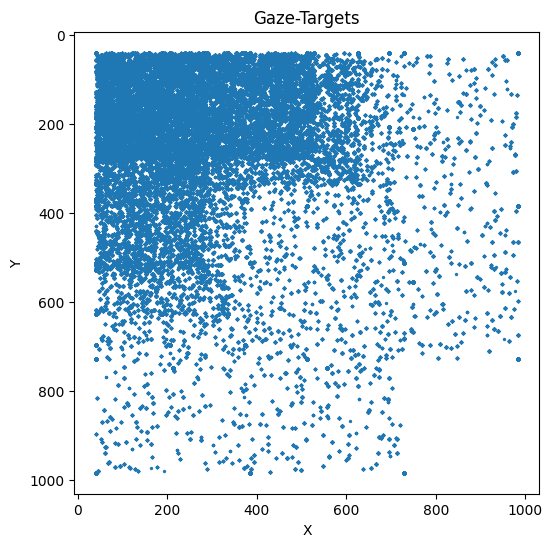

In [17]:
# PLOT:

# images_dir = "./datasets/images/"
labels_file = "./dataset/labels.csv"

df = pd.read_csv(labels_file)

# print(df.head())
# print("Anzahl Samples:", len(df))

x = df["x"]
y = df["y"]

# print(f"X_min: {np.min(x)}\t X_max: {np.max(x)}")
# print(f"Y_min: {np.min(y)}\t Y_max: {np.max(y)}")

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Gaze-Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()


X_min: 0.0390625	 X_max: 1.0
Y_min: 0.0390625	 Y_max: 1.0


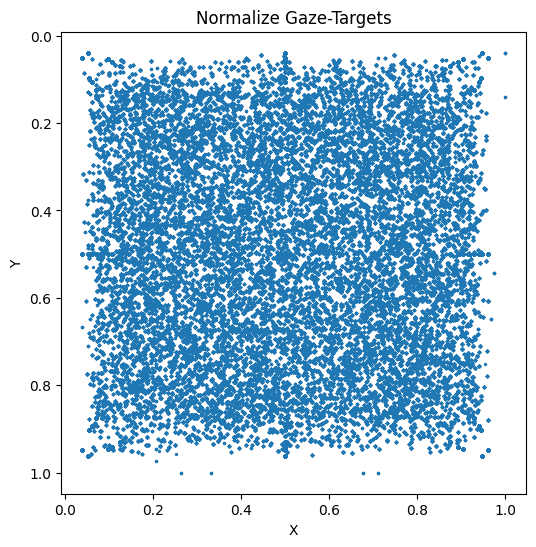

In [18]:

# Normalize:
norm_labels_file = './dataset/norm_labels.csv'

df2 = pd.read_csv(norm_labels_file)

x = df2["x"]
y = df2["y"]

print(f"X_min: {np.min(x)}\t X_max: {np.max(x)}")
print(f"Y_min: {np.min(y)}\t Y_max: {np.max(y)}")
"""
df = pd.read_csv("./dataset/norm_labels.csv")

errors = df[(df["x_norm"] > 1) | (df["y_norm"] > 1)]

print(errors)
"""

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Normalize Gaze-Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()

In [19]:
# Normalization: 
# -------------------------------------------------------------------
# ---------------------- Konstant_Error: -------------------------------
# -------------------------------------------------------------------

print("\nNormalization: \n")
df2 = pd.read_csv(norm_labels_file)



x_true = df2["x"].values
y_true = df2["y"].values

x_const = np.mean(x_true)
y_const = np.mean(y_true)

# x_const = 0.5
# y_const = 0.5

print(f"x_const: {x_const}")
print(f"y_const: {y_const}")

pred_x_const = np.full_like(x_true, x_const)
pred_y_const = np.full_like(y_true, y_const)

const_errors = np.sqrt(
    (x_true - pred_x_const) ** 2 +
    (y_true - pred_y_const) ** 2
)


mae = np.mean(const_errors)
rmse = np.sqrt(np.mean(const_errors ** 2))
const_error_pct = 100 * np.round(rmse, 5)
const_diagonal_error_pct = 100 * np.round(rmse / np.sqrt(2), 5)

print("\nKonstant Baseline:\n")
print(f"Constant_Mean_Absolute_Error: {mae}")
print(f"Constant_Mean_Squared_Error: {rmse}")
# print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
print(f"Constant_Diagonal-Error %: {const_diagonal_error_pct} %")



# -------------------------------------------------------------------
# --------------- x- and y-constant: 0.0, 0.0 -----------------------
# -------------------------------------------------------------------

# x_const = 0.0
# y_const = 0.0

# print(f"\nx_const: {x_const}")
# print(f"y_const: {y_const}")

# pred_x_const = np.full_like(x_true, x_const)
# pred_y_const = np.full_like(y_true, y_const)

# const_errors = np.sqrt(
#     (x_true - pred_x_const) ** 2 +
#     (y_true - pred_y_const) ** 2
# )


# mae = np.mean(const_errors)
# rmse = np.sqrt(np.mean(const_errors ** 2))
# const_error_pct = 100 * np.round(rmse, 5)
# const_diagonal_error_pct = 100 * np.round(rmse / np.sqrt(2), 5)

# print("\nKonstant Baseline:\n")
# print(f"Constant_Mean_Absolute_Error: {mae}")
# print(f"Constant_Mean_Squared_Error: {rmse}")
# print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
# print(f"Constant_Diagonal-Error %: {const_diagonal_error_pct} %")


# -------------------------------------------------------------------
# ---------------------- Random-Error -------------------------------
# -------------------------------------------------------------------

x = df2["x"]
y = df2["y"]
x_max = np.max(x)
x_min = np.min(x)
y_max = np.max(y)
y_min = np.min(y)

# x_max = 1.0
# y_max = 1.0


pred_x_random = np.random.uniform(x_min, x_max, len(x_true))
pred_y_random = np.random.uniform(y_min, y_max, len(y_true))

random_errors = np.sqrt(
    (x_true - pred_x_random)**2 +
    (y_true - pred_y_random)**2
)

mae = np.mean(random_errors)
rmse = np.sqrt(np.mean(random_errors ** 2))
random_error_pct = 100 * np.round(rmse, 5)
random_diagonal_error_pct = 100 * np.round(rmse / np.sqrt(2), 5)

print("\nRandom Baseline:\n")
print(f"Random_Mean_Absolute_Error: {mae}")
print(f"Random_Mean_Squared_Error: {rmse}")
# print(f"Random_Mean_Squared_Error %: {random_error_pct} %")
print(f"Random_Diagonal-Error %: {random_diagonal_error_pct} %")


Normalization: 

x_const: 0.5018271047520313
y_const: 0.5004797436472681

Konstant Baseline:

Constant_Mean_Absolute_Error: 0.35649399675432236
Constant_Mean_Squared_Error: 0.3852981815765823
Constant_Diagonal-Error %: 27.245 %

Random Baseline:

Random_Mean_Absolute_Error: 0.4972210571353635
Random_Mean_Squared_Error: 0.5510644653348393
Random_Diagonal-Error %: 38.966 %


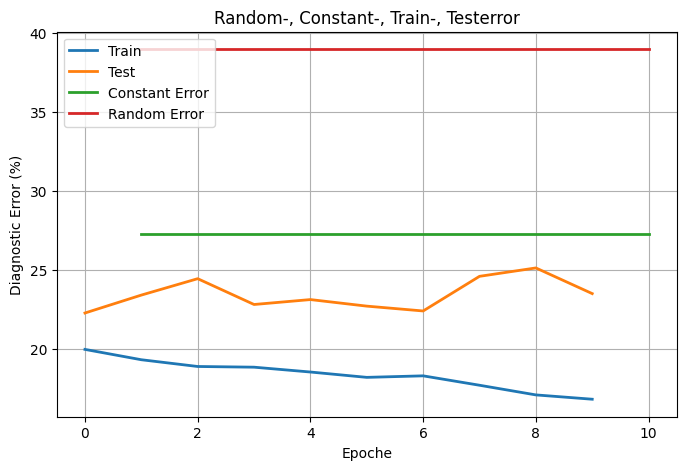

In [20]:
# Curven:

epochs = range(1, len(diag_test_error) + 1)
# epochs = range(1, 11)
plt.figure(figsize=(8, 5))

plt.plot(diag_train_error, label="Train", linewidth=2)
plt.plot(diag_test_error, label="Test", linewidth=2)


plt.plot(epochs, [const_diagonal_error_pct] * len(epochs),
         label="Constant Error", linewidth=2)

plt.plot(epochs, [random_diagonal_error_pct] * len(epochs),
         label="Random Error", linewidth=2)

# plt.plot(epochs, diag_test_error, marker='o', linewidth=2)

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")
plt.title("Random-, Constant-, Train-, Testerror")
plt.grid(True)
plt.legend()

plt.show()

                                        image_name    x_norm    y_norm  \
99106  dataset/images/00258/00258/frames/00009.jpg  0.262721  1.007969   
99107  dataset/images/00258/00258/frames/00010.jpg  0.262721  1.007969   
99108  dataset/images/00258/00258/frames/00011.jpg  0.262721  1.007969   
99115  dataset/images/00258/00258/frames/00018.jpg  0.331600  1.217468   
99116  dataset/images/00258/00258/frames/00019.jpg  0.331600  1.217468   
99117  dataset/images/00258/00258/frames/00020.jpg  0.331600  1.217468   
99124  dataset/images/00258/00258/frames/00027.jpg  1.281250  0.039062   
99125  dataset/images/00258/00258/frames/00028.jpg  1.281250  0.039062   
99126  dataset/images/00258/00258/frames/00029.jpg  1.281250  0.039062   
99161  dataset/images/00258/00258/frames/00064.jpg  0.710938  1.281250   
99162  dataset/images/00258/00258/frames/00065.jpg  0.710938  1.281250   
99163  dataset/images/00258/00258/frames/00066.jpg  0.710938  1.281250   
99172  dataset/images/00258/00258/fram

In [ ]:
# Inference
model.load_state_dict(
    torch.load(
        "gaze_model.pth"
    )
)

model.eval()

In [ ]:
predictions = []
targets_all = []

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device)
        preds = model(images)

        predictions.append(
            preds.cpu()
        )

        targets_all.append(
            targets
        )


predictions = torch.cat(
    predictions
)

targets_all = torch.cat(
    targets_all
)
